In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
GAMMA=0.9
ALPHA=.1
SMALL_ENOUGH=1e-3
ALL_POSSIBLE_ACTIONS=('U','D','L','R')

In [4]:
class Grid:
    def __init__(self,rows,cols,start):
        self.rows=rows
        self.cols=cols
        self.i=start[0]
        self.j=start[1]
    
    def set(self,rewards,actions):
        self.rewards=rewards
        self.actions=actions
        
    def reset(self):
        self.i=2
        self.j=0
        return (self.i,self.j)
    
    def set_state(self,s):
        self.i=s[0]
        self.j=s[1]
    
    def current_state(self):
        return (self.i,self.j)

    def is_terminal(self,s):
        return s not in self.actions

    def get_next_state(self,s,a):
        i,j=s[0],s[1]
        if a in self.actions[i,j]:
            if a=='U':
                i -=1
            if a=='D':
                i +=1
            if a=='L':
                j -=1
            if a=='R':
                j +=1
        return i,j

    def move (self,action):
        if action in self.actions[(self.i,self.j)]:
            if action =='U':
                self.i -=1
            if action =='D':
                self.i +=1
            if action =='R':
                self.j +=1
            if action =='L':
                self.j -=1
            
        return self.rewards.get((self.i,self.j),0)

    def undo_move (self,action):
        if action =='U':
            self.i +=1
        if action =='D':
            self.i -=1
        if action =='R':
            self.j -=1
        if action =='L':
            self.j +=1
        assert(self.current_state() in self.all_stats())

    def game_over (self):
        return (self.i,self.j) not in self.actions

    def all_states(self):
        return set(self.actions.keys()) | set (self.rewards.keys())

In [5]:
def print_values(V,g):
    for i in range (g.rows):
        print("--------------------------")
        for j in range(g.cols):
            v=V.get((i,j),0)
            if v >=0:
                print(" %.2f |"% v,end="")
            else:
                print("%.2f |" %v,end="")
        print("")
        
        
def print_policy(P,g):
    for i in range(g.rows):
        print("----------------------------")
        for j in range(g.cols):
            a=P.get((i,j),' ')
            print(" %s |" %a,end="")
        print("")
    


In [6]:
def standard_grid():
    g=Grid(3,4,(2,0))
    rewards={(0,3):1,(1,3):-1}

    actions={
        (0,0):('D','R'),
        (0,1):('L','R'),
        (0,2):('L','R','D'),
        (1,0):('U','D'),
        (1,2):('R','U','D'),
        (2,0):('U','R'),
        (2,1):('L','R'),
        (2,2):('L','R','U'),
        (2,3):('L','U')
    }
    
    
    g.set(rewards,actions)
    return g
    

In [7]:
def epsilon_greedy(policy,s,eps=.1):
    p=np.random.random()
    if p <(1-eps):
        return policy[s]
    else:
        return np.random.choice(ALL_POSSIBLE_ACTIONS)

rewards:
--------------------------
 0.00 | 0.00 | 0.00 | 1.00 |
--------------------------
 0.00 | 0.00 | 0.00 |-1.00 |
--------------------------
 0.00 | 0.00 | 0.00 | 0.00 |


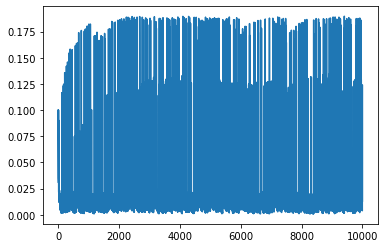

values:
--------------------------
 0.73 | 0.85 | 0.98 | 0.00 |
--------------------------
 0.63 | 0.00 |-0.99 | 0.00 |
--------------------------
 0.44 |-0.78 |-0.89 |-0.99 |
policy:
----------------------------
 R | R | R |   |
----------------------------
 U |   | R |   |
----------------------------
 U | R | R | U |


In [9]:
if __name__ =='__main__':
    grid=standard_grid()
    
    print('rewards:')
    print_values(grid.rewards,grid)
    
    policy={
        (2,0):'U',
        (1,0):'U',
        (0,0):'R',
        (0,1):'R',
        (0,2):'R',
        (1,2):'R',
        (2,1):'R',
        (2,2):'R',
        (2,3):'U',
    }
    
    V={}
    states=grid.all_states()
    for s in states:
        V[s]=0
        
    deltas=[]
    
    n_episodes=10000
    for it in range (n_episodes):
        s=grid.reset()
        delta=0
        
        while not grid.game_over():
            a= epsilon_greedy(policy,s)
            r=grid.move(a)
            
            s_next=grid.current_state()
            
            v_old=V[s]
            V[s]=V[s]+ ALPHA * (r+GAMMA*V[s_next]-V[s])
            delta=max(delta,np.abs(V[s]-v_old))
            
            s=s_next
            
        deltas.append(delta)
        
    plt.plot(deltas)
    plt.show()
    
    print("values:")
    print_values(V,grid)
    print('policy:')
    print_policy(policy,grid)
    
